In [1]:
# ============================================================================
# CONTEXTUAL MULTI-ARM BANDIT: STUDENT LEARNING EXAMPLE
# ============================================================================
# In this notebook, we'll implement a contextual multi-arm bandit (CMAB) 
# following the analogy of a teacher offering different lesson types to students.
#
# Problem Setup:
# - Context: Each student has features (prior knowledge, study hours, aptitude)
# - Arms: Different lesson types (visual, auditory, hands-on)
# - Reward: Student's test score after the lesson
# - Goal: Learn which lesson type works best for which type of student
#
# The teacher doesn't know upfront which lesson type is best for each student type,
# so they must balance exploration (trying different lessons) with exploitation 
# (using the best-known lesson type).
# ============================================================================

# 1. IMPORT REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
sns.set_style("whitegrid")

In [2]:
# ============================================================================
# 2. DEFINE THE GROUND TRUTH REWARD FUNCTION
# ============================================================================
# This function represents the TRUE relationship between student features and 
# lesson effectiveness. In reality, the teacher doesn't know this function - 
# they must learn it through interaction.
# ============================================================================

class GroundTruthRewardFunction:
    """
    Hidden ground truth function that generates student test scores.
    
    Student context has 3 features:
    - Feature 0: Prior knowledge (0-1)
    - Feature 1: Study hours per week (0-1, normalized)
    - Feature 2: Mathematical aptitude (0-1)
    
    Lesson types (arms):
    - 0: Visual lessons (diagrams, videos)
    - 1: Auditory lessons (lectures, discussions)
    - 2: Hands-on lessons (projects, experiments)
    """
    
    def __init__(self):
        # True coefficients for each lesson type (unknown to the bandit)
        # Each row represents how features affect test scores for that lesson type
        # More exaggerated weights to create clearer differentiation
        self.true_weights = {
            0: np.array([0.05, 0.05, 1.0]),  # Visual: VERY strongly benefits high aptitude students
            1: np.array([1.0, 0.05, 0.05]),  # Auditory: VERY strongly benefits those with prior knowledge
            2: np.array([0.05, 1.0, 0.05])   # Hands-on: VERY strongly benefits those who study more
        }
        
        # Base scores for each lesson type (equal baseline to ensure fairness)
        self.base_scores = {
            0: 60,  # Visual baseline
            1: 60,  # Auditory baseline
            2: 60   # Hands-on baseline
        }
        
        # Noise level in test scores
        self.noise_std = 5.0
    
    def get_expected_reward(self, context, arm):
        """
        Get the expected test score without noise (ground truth).
        
        This version intentionally exaggerates non-linearities so the *optimal policy*
        is easy to see in the decision boundary plots.
        
        Args:
            context: numpy array of shape (3,) with student features
            arm: integer 0, 1, or 2 representing lesson type
            
        Returns:
            expected_score: float representing the true expected score (no noise)
        """
        prior, study, aptitude = context

        # Linear component (kept from the original ground truth)
        linear_score = np.dot(self.true_weights[arm], context) * 30

        # Strong non-linear component (arm-specific)
        # Using smooth functions (tanh/sin) to create obvious curved boundaries.
        if arm == 0:  # Visual
            # Visual has a strong "aptitude threshold" effect + interaction wiggles
            nonlinear = (
                28.0 * np.tanh(6.0 * (aptitude - 0.55))
                + 18.0 * np.sin(2.0 * np.pi * study * aptitude)
                - 14.0 * (aptitude - 0.85) ** 2
            )
        elif arm == 1:  # Auditory
            # Auditory has a strong "prior threshold" effect + prior×aptitude interaction
            nonlinear = (
                28.0 * np.tanh(6.0 * (prior - 0.55))
                + 16.0 * np.sin(2.0 * np.pi * prior * aptitude)
                - 14.0 * (prior - 0.80) ** 2
            )
        else:  # Hands-on (arm == 2)
            # Hands-on has a strong "study threshold" effect + study×aptitude interaction
            nonlinear = (
                30.0 * np.tanh(6.0 * (study - 0.50))
                + 20.0 * np.sin(2.0 * np.pi * study)
                + 18.0 * (study * aptitude)
                - 10.0 * (1.0 - study) ** 2
            )

        return self.base_scores[arm] + linear_score + nonlinear
    
    def get_reward(self, context, arm):
        """
        Generate a test score for a student given their context and lesson type.
        
        Args:
            context: numpy array of shape (3,) with student features
            arm: integer 0, 1, or 2 representing lesson type
            
        Returns:
            test_score: float
        """
        # Calculate expected score based on true relationship
        expected_score = self.get_expected_reward(context, arm)
        
        # Add random noise to simulate real-world variability
        actual_score = expected_score + np.random.normal(0, self.noise_std)
        
        return actual_score
    
    def get_optimal_arm(self, context):
        """
        Returns the best lesson type for a given student (oracle knowledge).
        
        Args:
            context: numpy array of shape (3,) with student features
            
        Returns:
            optimal_arm: integer representing best lesson type
        """
        expected_rewards = [
            self.get_expected_reward(context, arm)
            for arm in range(3)
        ]
        return np.argmax(expected_rewards)


In [3]:
# ============================================================================
# TEST THE GROUND TRUTH FUNCTION
# ============================================================================
# Let's verify that different lesson types work better for different student types.
# ============================================================================

ground_truth = GroundTruthRewardFunction()

# Example student profiles
students = {
    "High Aptitude": np.array([0.5, 0.5, 0.9]),  # High math aptitude
    "Prior Knowledge": np.array([0.9, 0.5, 0.5]),  # High prior knowledge
    "Hard Worker": np.array([0.5, 0.9, 0.5])  # Studies a lot
}

lesson_types = {0: "Visual", 1: "Auditory", 2: "Hands-on"}

print("Average test scores for different student types and lesson types:\n")
for student_name, context in students.items():
    print(f"{student_name} Student:")
    for arm, lesson_name in lesson_types.items():
        # Average over multiple trials to reduce noise
        scores = [ground_truth.get_reward(context, arm) for _ in range(100)]
        avg_score = np.mean(scores)
        is_best = (arm == ground_truth.get_optimal_arm(context))
        marker = " ⭐ BEST" if is_best else ""
        print(f"  {lesson_name:12s}: {avg_score:.1f}{marker}")
    print()

Average test scores for different student types and lesson types:

High Aptitude Student:
  Visual      : 120.7 ⭐ BEST
  Auditory    : 72.7
  Hands-on    : 83.0

Prior Knowledge Student:
  Visual      : 85.8
  Auditory    : 120.2 ⭐ BEST
  Hands-on    : 78.5

Hard Worker Student:
  Visual      : 72.9
  Auditory    : 83.7
  Hands-on    : 115.4 ⭐ BEST



In [4]:
# ============================================================================
# 3. IMPLEMENT THE CONTEXTUAL MULTI-ARM BANDIT
# ============================================================================
# Now we'll build a CMAB that learns which lesson type to recommend for each
# student type using a SINGLE XGBOOST model and an EPSILON-GREEDY exploration strategy.
#
# IMPORTANT: We treat the arm/lesson type as a *categorical* feature (not one-hot).
# XGBoost supports native categorical splits when `enable_categorical=True`.
# ============================================================================

class ContextualBandit:
    """
    Contextual Multi-Arm Bandit using XGBoost for reward prediction.
    Uses epsilon-greedy strategy for exploration vs exploitation.

    We model reward as a function of:
      - student context features (prior knowledge, study hours, aptitude)
      - lesson type / arm (categorical)

    Using a single categorical arm feature avoids one-hot expansion and lets
    XGBoost learn arm-specific effects and interactions via categorical splits.
    """

    def __init__(self, n_arms=3, n_features=3, epsilon=0.1):
        """Initialize the bandit.

        Args:
            n_arms: Number of lesson types (arms)
            n_features: Number of student features (context dimensions)
            epsilon: Exploration rate (0 = always exploit, 1 = always explore)
        """
        self.n_arms = n_arms
        self.n_features = n_features
        self.epsilon = epsilon

        # XGBoost regressor model
        # Input: [context (3) + arm (1 categorical)] = 4 features
        self.model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            random_state=42,
            verbosity=0,
            tree_method="hist",
            enable_categorical=True,
        )

        # Store all training data
        # Each row is a dict with keys: prior_knowledge, study_hours, aptitude, arm
        self.X_train = []
        self.y_train = []

        # Track if model has been trained
        self.is_trained = False

    def _make_row(self, context, arm):
        """Create a single training row as a python dict."""
        prior, study, aptitude = context
        return {
            "prior_knowledge": float(prior),
            "study_hours": float(study),
            "aptitude": float(aptitude),
            "arm": int(arm),
        }

    def _make_frame(self, rows):
        """Convert one or many rows to a pandas DataFrame with categorical arm."""
        X = pd.DataFrame(rows)
        X["arm"] = pd.Categorical(X["arm"], categories=list(range(self.n_arms)))
        return X

    def select_arm(self, context):
        """Select which lesson type to use (epsilon-greedy strategy)."""
        # Exploration: choose random arm with probability epsilon
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)

        # Exploitation: choose arm with highest predicted reward
        # If model not trained yet, explore randomly
        if not self.is_trained:
            return np.random.randint(self.n_arms)

        predicted_rewards = []
        for arm in range(self.n_arms):
            X_row = self._make_frame([self._make_row(context, arm)])
            pred = float(self.model.predict(X_row)[0])
            predicted_rewards.append(pred)

        return int(np.argmax(predicted_rewards))

    def update(self, context, arm, reward):
        """Update the XGBoost model with new (context, arm, reward) observation."""
        self.X_train.append(self._make_row(context, arm))
        self.y_train.append(float(reward))

        # Retrain the model if we have enough data
        if len(self.X_train) >= 2:  # Need at least 2 samples
            X = self._make_frame(self.X_train)
            y = np.array(self.y_train)
            self.model.fit(X, y)
            self.is_trained = True

    def predict_best_arm(self, context):
        """Predict the best arm for a given context (pure exploitation)."""
        if not self.is_trained:
            return 0  # Default to first arm if nothing trained

        predicted_rewards = []
        for arm in range(self.n_arms):
            X_row = self._make_frame([self._make_row(context, arm)])
            pred = float(self.model.predict(X_row)[0])
            predicted_rewards.append(pred)

        return int(np.argmax(predicted_rewards))


In [5]:
# ============================================================================
# 4. STUDENT CLASS GENERATOR (FRESH EACH EPOCH)
# ============================================================================
# To avoid overfitting to the *same* students, we'll generate a new class of
# students each epoch.
#
# Tweak (smoother population): we sample student features from a simple base
# distribution (Uniform[0,1]^3) and then *select* a class with an approximate
# 60/30/10 mix of optimal lesson types. This avoids "hand-crafting" feature
# ranges per arm while still keeping class composition controlled.
# ============================================================================

CLASS_SIZE = 100
TARGET_COUNTS = {0: 60, 1: 30, 2: 10}  # Visual / Auditory / Hands-on optimal counts


def generate_student_class(
    ground_truth,
    class_size=CLASS_SIZE,
    target_counts=TARGET_COUNTS,
    pool_multiplier=30,
):
    """Generate a fresh class of students.

    By default, contexts are sampled from a smooth base distribution
    (Uniform[0,1]^3). If `target_counts` is provided, we then stratify by the
    *true* optimal arm (oracle) and sample a class with that mix.

    Returns:
        List of dicts: {id, context, optimal_arm}
    """
    if target_counts is None:
        contexts = np.random.random((class_size, 3))
        student_class = []
        for student_id, context in enumerate(contexts):
            optimal_arm = int(ground_truth.get_optimal_arm(context))
            student_class.append({"id": student_id, "context": context, "optimal_arm": optimal_arm})
        return student_class

    # If target_counts doesn't sum to class_size, treat it as proportions.
    target_sum = sum(int(v) for v in target_counts.values())
    if target_sum != class_size:
        # Convert to proportions then to integer counts that sum to class_size
        weights = {arm: float(v) / float(target_sum) for arm, v in target_counts.items()}
        counts = {arm: int(round(weights.get(arm, 0.0) * class_size)) for arm in range(3)}
        # Fix rounding drift
        drift = class_size - sum(counts.values())
        if drift != 0:
            # Add/subtract to the most common arm
            best_arm = max(counts.items(), key=lambda x: x[1])[0]
            counts[best_arm] += drift
        target_counts = counts

    pool_size = max(class_size * pool_multiplier, class_size)

    # Build a candidate pool from the base distribution
    contexts = np.random.random((pool_size, 3))
    optimal_arms = np.array([int(ground_truth.get_optimal_arm(c)) for c in contexts], dtype=int)

    selected_contexts = []
    selected_optimal_arms = []

    for arm in range(3):
        need = int(target_counts.get(arm, 0))
        if need <= 0:
            continue

        idxs = np.where(optimal_arms == arm)[0]

        # If the pool doesn't contain enough of a given arm, resample a bigger pool.
        # (This keeps the feature distribution smooth without hand-crafting.)
        if len(idxs) < need:
            # Increase pool and try once more
            extra_pool_size = max((need - len(idxs)) * 50, class_size * 10)
            extra_contexts = np.random.random((extra_pool_size, 3))
            extra_optimal_arms = np.array([int(ground_truth.get_optimal_arm(c)) for c in extra_contexts], dtype=int)

            contexts = np.vstack([contexts, extra_contexts])
            optimal_arms = np.concatenate([optimal_arms, extra_optimal_arms])
            idxs = np.where(optimal_arms == arm)[0]

        if len(idxs) == 0:
            raise RuntimeError(
                f"Could not sample any students with optimal arm={arm}. "
                "Try increasing pool_multiplier or adjusting the ground truth." 
            )

        replace = len(idxs) < need
        chosen = np.random.choice(idxs, size=need, replace=replace)
        selected_contexts.append(contexts[chosen])
        selected_optimal_arms.append(np.full(need, arm, dtype=int))

    contexts_final = np.vstack(selected_contexts)
    optimal_arms_final = np.concatenate(selected_optimal_arms)

    # Shuffle so the class isn't ordered by arm
    perm = np.random.permutation(len(contexts_final))
    contexts_final = contexts_final[perm]
    optimal_arms_final = optimal_arms_final[perm]

    student_class = []
    for student_id, (context, optimal_arm) in enumerate(zip(contexts_final, optimal_arms_final)):
        student_class.append({"id": student_id, "context": context, "optimal_arm": int(optimal_arm)})

    return student_class


# Generate ONE example class just to visualize what the population looks like
student_class = generate_student_class(ground_truth, class_size=CLASS_SIZE, target_counts=TARGET_COUNTS)

print(f"Example class of {CLASS_SIZE} students (used for display only):\n")
print(f"{'ID':<5} {'Prior':<8} {'Study':<8} {'Aptitude':<8} {'Optimal Lesson':<15}")
print("-" * 60)
for i in [0, 20, 40, 60, 80, 90]:
    s = student_class[i]
    lesson_name = {0: "Visual", 1: "Auditory", 2: "Hands-on"}[s['optimal_arm']]
    print(f"{s['id']:<5} {s['context'][0]:<8.3f} {s['context'][1]:<8.3f} {s['context'][2]:<8.3f} {lesson_name:<15}")

# Show distribution of optimal lessons in the example class
optimal_counts = {0: 0, 1: 0, 2: 0}
for s in student_class:
    optimal_counts[s['optimal_arm']] += 1

print("\nExample class composition by optimal lesson type:")
for arm, count in optimal_counts.items():
    lesson_name = {0: "Visual", 1: "Auditory", 2: "Hands-on"}[arm]
    print(f"  {lesson_name:12s}: {count:2d} students ({count/CLASS_SIZE*100:.1f}%)")


Example class of 100 students (used for display only):

ID    Prior    Study    Aptitude Optimal Lesson 
------------------------------------------------------------
0     0.091    0.263    0.875    Visual         
20    0.468    0.071    0.598    Visual         
40    0.395    0.322    0.610    Visual         
60    0.864    0.473    0.968    Visual         
80    0.763    0.759    0.886    Hands-on       
90    0.909    0.370    0.751    Visual         

Example class composition by optimal lesson type:
  Visual      : 60 students (60.0%)
  Auditory    : 30 students (30.0%)
  Hands-on    : 10 students (10.0%)


In [6]:

# ============================================================================
# 5. TRAINING THE BANDIT (NEW CLASS EACH EPOCH)
# ============================================================================
# Each epoch, we sample a fresh class of students from the same population.
# This avoids repeatedly fitting on the exact same individuals.
# ============================================================================

def train_bandit(
    bandit,
    ground_truth,
    class_size=CLASS_SIZE,
    target_counts=TARGET_COUNTS,
    n_epochs=20,
    verbose=True,
):
    """Train the contextual bandit over multiple epochs.

    For each epoch, we generate a new class of students and run one interaction
    with each student (one pass = one epoch).

    Args:
        bandit: ContextualBandit instance
        ground_truth: GroundTruthRewardFunction instance
        class_size: Students per epoch
        target_counts: Desired optimal-arm distribution in each sampled class
        n_epochs: Number of epochs
        verbose: Whether to print progress

    Returns:
        history: Dictionary with training metrics
    """
    history = {
        "round": [],
        "epoch": [],
        "student_id": [],
        "reward": [],
        "optimal_arm": [],
        "selected_arm": [],
        "cumulative_reward": [],
        "cumulative_optimal_reward": [],
        "regret": [],
        "epoch_accuracy": [],
    }

    cumulative_reward = 0.0
    cumulative_optimal_reward = 0.0
    round_num = 0

    for epoch in range(n_epochs):
        student_class = generate_student_class(
            ground_truth,
            class_size=class_size,
            target_counts=target_counts,
        )

        epoch_correct = 0
        epoch_total = len(student_class)

        for student in student_class:
            context = student["context"]
            student_id = student["id"]

            selected_arm = bandit.select_arm(context)
            reward = float(ground_truth.get_reward(context, selected_arm))

            optimal_arm = int(student["optimal_arm"])
            optimal_reward = float(ground_truth.get_reward(context, optimal_arm))

            bandit.update(context, selected_arm, reward)

            if selected_arm == optimal_arm:
                epoch_correct += 1

            cumulative_reward += reward
            cumulative_optimal_reward += optimal_reward
            regret = cumulative_optimal_reward - cumulative_reward

            history["round"].append(round_num)
            history["epoch"].append(epoch)
            history["student_id"].append(student_id)
            history["reward"].append(reward)
            history["optimal_arm"].append(optimal_arm)
            history["selected_arm"].append(selected_arm)
            history["cumulative_reward"].append(cumulative_reward)
            history["cumulative_optimal_reward"].append(cumulative_optimal_reward)
            history["regret"].append(regret)
            history["epoch_accuracy"].append(None)

            round_num += 1

        epoch_accuracy = epoch_correct / epoch_total * 100

        epoch_start = epoch * epoch_total
        for i in range(epoch_start, round_num):
            history["epoch_accuracy"][i] = epoch_accuracy

        if verbose:
            avg_reward = cumulative_reward / round_num
            print(
                f"Epoch {epoch+1:2d}/{n_epochs}: Accuracy = {epoch_accuracy:5.1f}%, "
                f"Avg Reward = {avg_reward:.2f}, Regret = {regret:.2f}"
            )

    return history


In [7]:
# Train the bandit with epsilon = 0.1
print("=" * 60)
print("Training Contextual Bandit (epsilon = 0.1)")
print("=" * 60)

bandit = ContextualBandit(n_arms=3, n_features=3, epsilon=0.1)
history = train_bandit(
    bandit,
    ground_truth,
    class_size=CLASS_SIZE,
    target_counts=TARGET_COUNTS,
    n_epochs=20,
)


Training Contextual Bandit (epsilon = 0.1)
Epoch  1/20: Accuracy =  70.0%, Avg Reward = 95.99, Regret = 972.97
Epoch  2/20: Accuracy =  83.0%, Avg Reward = 99.50, Regret = 1374.16
Epoch  3/20: Accuracy =  80.0%, Avg Reward = 100.30, Regret = 1911.00
Epoch  4/20: Accuracy =  80.0%, Avg Reward = 101.24, Regret = 2672.27
Epoch  5/20: Accuracy =  88.0%, Avg Reward = 101.85, Regret = 2994.76
Epoch  6/20: Accuracy =  86.0%, Avg Reward = 102.40, Regret = 3413.83
Epoch  7/20: Accuracy =  89.0%, Avg Reward = 102.75, Regret = 3683.38
Epoch  8/20: Accuracy =  93.0%, Avg Reward = 103.78, Regret = 3937.03
Epoch  9/20: Accuracy =  81.0%, Avg Reward = 103.65, Regret = 4417.63
Epoch 10/20: Accuracy =  82.0%, Avg Reward = 103.41, Regret = 4874.12
Epoch 11/20: Accuracy =  87.0%, Avg Reward = 103.46, Regret = 5198.44
Epoch 12/20: Accuracy =  89.0%, Avg Reward = 103.65, Regret = 5476.24
Epoch 13/20: Accuracy =  82.0%, Avg Reward = 103.51, Regret = 5901.49
Epoch 14/20: Accuracy =  87.0%, Avg Reward = 103.8

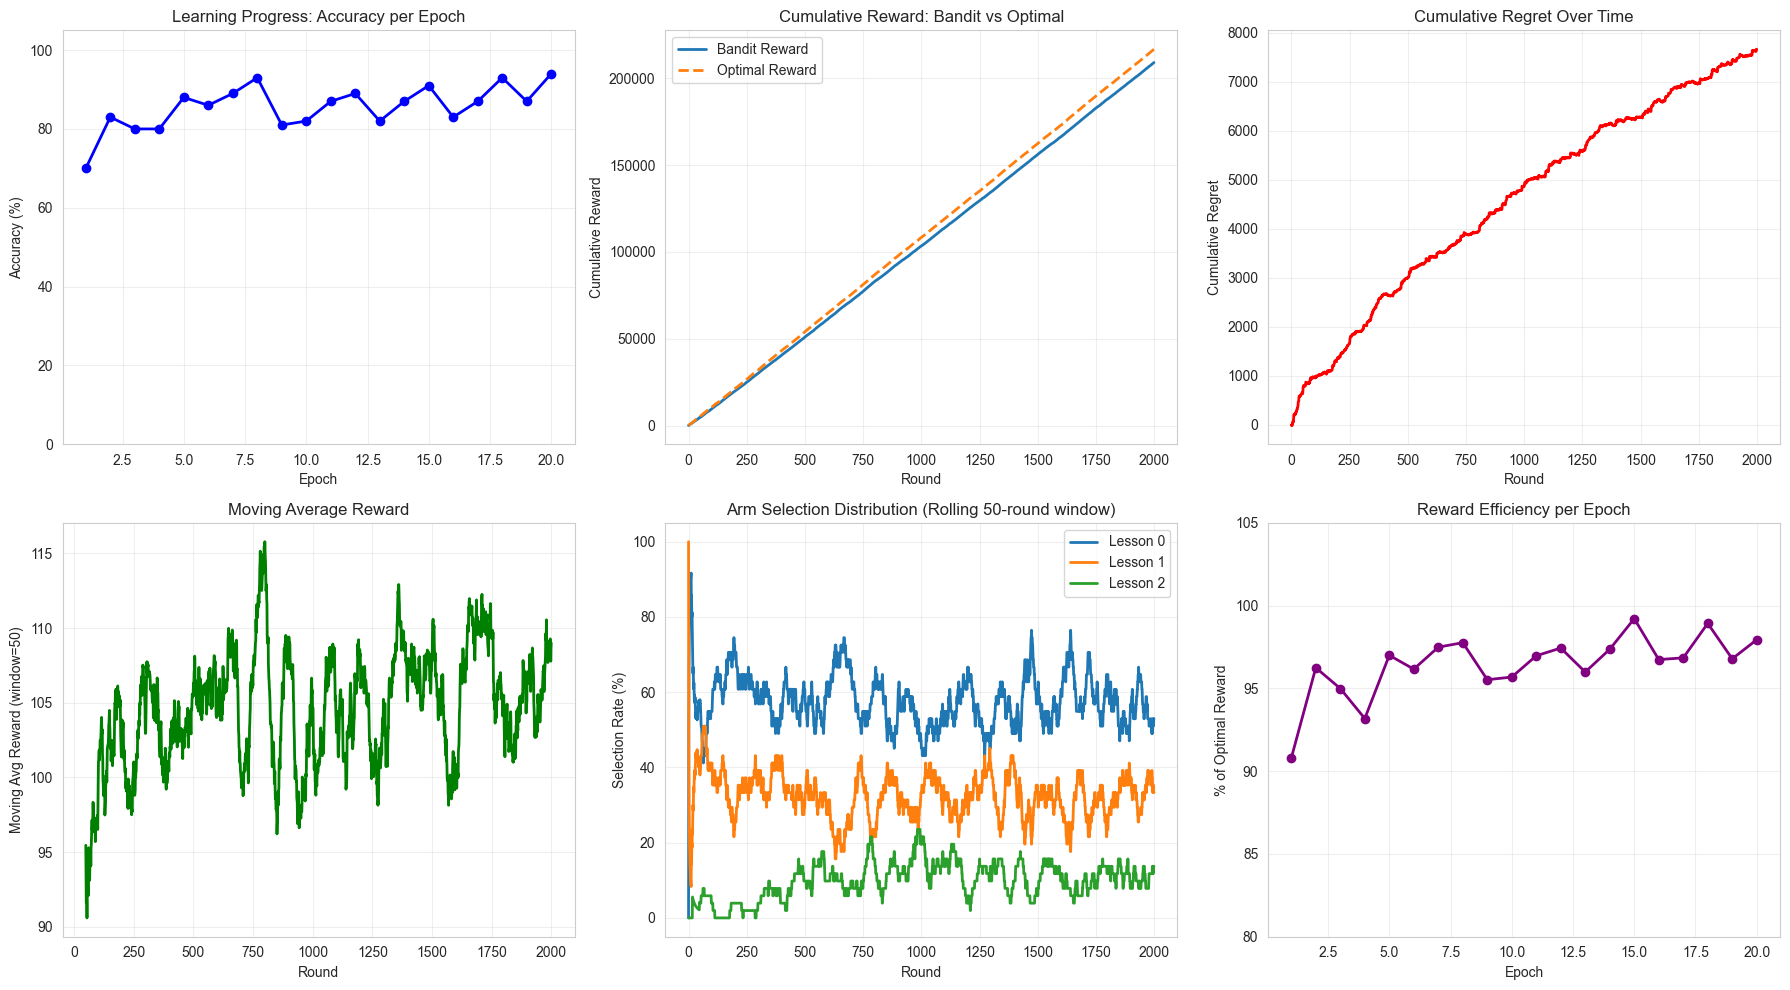


Final Training Statistics
Total Epochs: 20
Total Rounds: 2000
Students per Epoch: 100

Final Epoch Accuracy: 94.0%
First Epoch Accuracy: 70.0%
Improvement: +24.0 percentage points

Total Reward Achieved: 209111.03
Optimal Reward Possible: 216775.88
Final Regret: 7664.85
Overall % of Optimal: 96.46%


In [8]:
# ============================================================================
# VISUALIZE TRAINING PERFORMANCE
# ============================================================================
# We sample a fresh class each epoch, but the class size stays constant.
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Epoch Accuracy
# Extract one accuracy value per epoch
epochs = []
accuracies = []
class_size = CLASS_SIZE
n_epochs = max(history['epoch']) + 1

for epoch in range(n_epochs):
    epoch_idx = epoch * class_size  # First round of this epoch
    if epoch_idx < len(history['epoch_accuracy']):
        epochs.append(epoch + 1)
        accuracies.append(history['epoch_accuracy'][epoch_idx])

axes[0, 0].plot(epochs, accuracies, marker='o', linewidth=2, markersize=6, color='blue')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Learning Progress: Accuracy per Epoch')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 105])

# Plot 2: Cumulative Reward vs Optimal
axes[0, 1].plot(history['round'], history['cumulative_reward'], label='Bandit Reward', linewidth=2)
axes[0, 1].plot(history['round'], history['cumulative_optimal_reward'],
                label='Optimal Reward', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Cumulative Reward')
axes[0, 1].set_title('Cumulative Reward: Bandit vs Optimal')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Cumulative Regret
axes[0, 2].plot(history['round'], history['regret'], color='red', linewidth=2)
axes[0, 2].set_xlabel('Round')
axes[0, 2].set_ylabel('Cumulative Regret')
axes[0, 2].set_title('Cumulative Regret Over Time')
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Moving Average Reward
window_size = 50
moving_avg = pd.Series(history['reward']).rolling(window=window_size).mean()
axes[1, 0].plot(history['round'], moving_avg, linewidth=2, color='green')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel(f'Moving Avg Reward (window={window_size})')
axes[1, 0].set_title('Moving Average Reward')
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Arm Selection Distribution Over Time
arm_counts = {0: [], 1: [], 2: []}
window = 50
for i in range(len(history['selected_arm'])):
    start_idx = max(0, i - window)
    recent_selections = history['selected_arm'][start_idx:i+1]
    for arm in range(3):
        count = recent_selections.count(arm)
        arm_counts[arm].append(count / len(recent_selections) * 100)

for arm in range(3):
    axes[1, 1].plot(history['round'], arm_counts[arm],
                    label=f'Lesson {arm}', linewidth=2)
axes[1, 1].set_xlabel('Round')
axes[1, 1].set_ylabel('Selection Rate (%)')
axes[1, 1].set_title(f'Arm Selection Distribution (Rolling {window}-round window)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Percentage of Optimal per Epoch
pct_optimal_per_epoch = []
for epoch in range(n_epochs):
    epoch_start = epoch * class_size
    epoch_end = (epoch + 1) * class_size
    epoch_reward = history['cumulative_reward'][epoch_end - 1]
    epoch_optimal = history['cumulative_optimal_reward'][epoch_end - 1]
    if epoch > 0:
        epoch_reward -= history['cumulative_reward'][epoch_start - 1]
        epoch_optimal -= history['cumulative_optimal_reward'][epoch_start - 1]
    pct = epoch_reward / epoch_optimal * 100 if epoch_optimal > 0 else 0
    pct_optimal_per_epoch.append(pct)

axes[1, 2].plot(range(1, n_epochs + 1), pct_optimal_per_epoch,
                marker='o', linewidth=2, markersize=6, color='purple')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('% of Optimal Reward')
axes[1, 2].set_title('Reward Efficiency per Epoch')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_ylim([80, 105])

plt.tight_layout()
plt.show()

# Print final statistics
print("\n" + "=" * 80)
print("Final Training Statistics")
print("=" * 80)
print(f"Total Epochs: {n_epochs}")
print(f"Total Rounds: {len(history['round'])}")
print(f"Students per Epoch: {class_size}")
print(f"\nFinal Epoch Accuracy: {accuracies[-1]:.1f}%")
print(f"First Epoch Accuracy: {accuracies[0]:.1f}%")
print(f"Improvement: +{accuracies[-1] - accuracies[0]:.1f} percentage points")
print(f"\nTotal Reward Achieved: {history['cumulative_reward'][-1]:.2f}")
print(f"Optimal Reward Possible: {history['cumulative_optimal_reward'][-1]:.2f}")
print(f"Final Regret: {history['regret'][-1]:.2f}")
print(f"Overall % of Optimal: {history['cumulative_reward'][-1] / history['cumulative_optimal_reward'][-1] * 100:.2f}%")


Training bandits with different exploration rates...

Training with epsilon = 0.0
  Final epoch accuracy: 86.0%
  Final regret: 6471.31

Training with epsilon = 0.05
  Final epoch accuracy: 87.0%
  Final regret: 6326.07

Training with epsilon = 0.1
  Final epoch accuracy: 87.0%
  Final regret: 8285.21

Training with epsilon = 0.2
  Final epoch accuracy: 82.0%
  Final regret: 14971.32

Training with epsilon = 0.3
  Final epoch accuracy: 71.0%
  Final regret: 20458.38



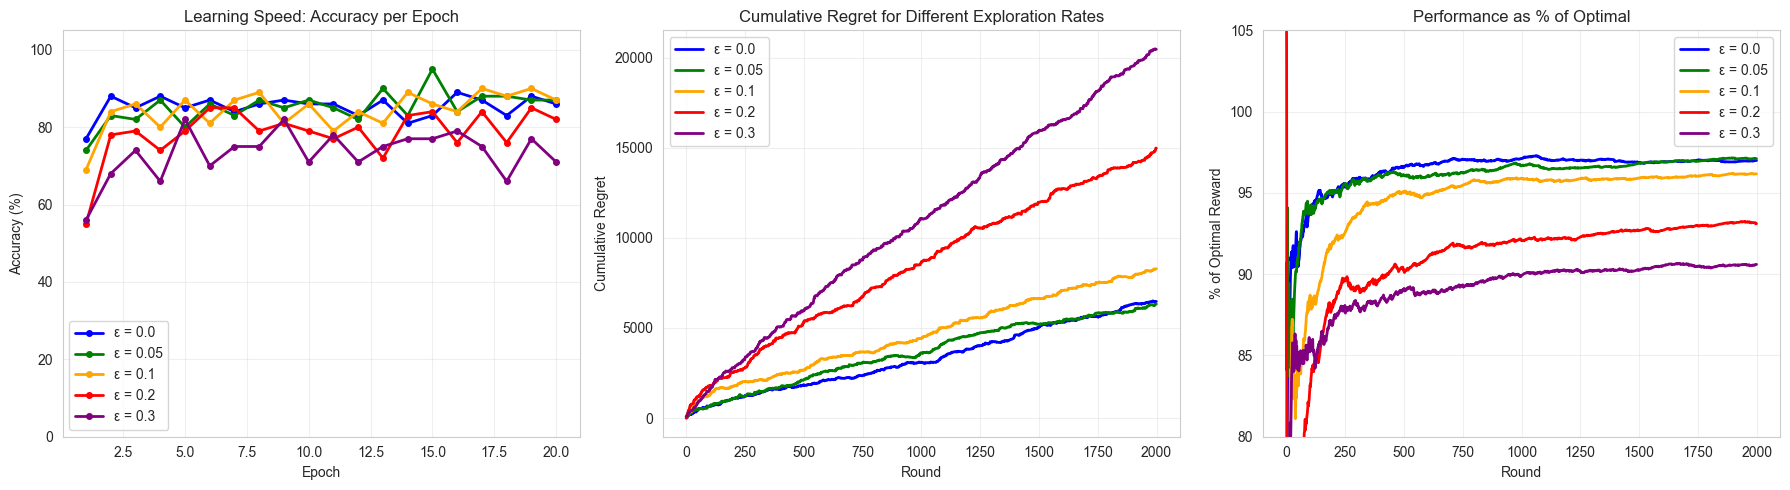


Exploration Strategy Comparison (after 20 epochs, 2000 total rounds)
 Epsilon   | Final Accuracy  |  Final Regret   |  % of Optimal  
--------------------------------------------------------------------------------
   0.00    |      86.0       |     6471.31     |      96.99     
   0.05    |      87.0       |     6326.07     |      97.11     
   0.10    |      87.0       |     8285.21     |      96.17     
   0.20    |      82.0       |    14971.32     |      93.11     
   0.30    |      71.0       |    20458.38     |      90.60     


In [9]:
# ============================================================================
# 6. COMPARE DIFFERENT EXPLORATION STRATEGIES
# ============================================================================
# Compare different epsilon values when each epoch samples a fresh class.
# ============================================================================

epsilon_values = [0.0, 0.05, 0.1, 0.2, 0.3]
results = {}

print("Training bandits with different exploration rates...\n")

for eps in epsilon_values:
    print(f"Training with epsilon = {eps}")
    bandit = ContextualBandit(n_arms=3, n_features=3, epsilon=eps)
    history = train_bandit(
        bandit,
        ground_truth,
        class_size=CLASS_SIZE,
        target_counts=TARGET_COUNTS,
        n_epochs=20,
        verbose=False,
    )
    results[eps] = history

    n_epochs = max(history['epoch']) + 1
    final_epoch_idx = (n_epochs - 1) * CLASS_SIZE
    final_accuracy = history['epoch_accuracy'][final_epoch_idx]

    print(f"  Final epoch accuracy: {final_accuracy:.1f}%")
    print(f"  Final regret: {history['regret'][-1]:.2f}\n")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Accuracy Learning Curves
axes[0].set_prop_cycle(color=['blue', 'green', 'orange', 'red', 'purple'])
for eps in epsilon_values:
    n_epochs = max(results[eps]['epoch']) + 1
    epochs = []
    accuracies = []
    for epoch in range(n_epochs):
        epoch_idx = epoch * CLASS_SIZE
        epochs.append(epoch + 1)
        accuracies.append(results[eps]['epoch_accuracy'][epoch_idx])

    axes[0].plot(epochs, accuracies, label=f'ε = {eps}', linewidth=2, marker='o', markersize=4)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Learning Speed: Accuracy per Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 105])

# Plot 2: Cumulative Regret
axes[1].set_prop_cycle(color=['blue', 'green', 'orange', 'red', 'purple'])
for eps in epsilon_values:
    axes[1].plot(results[eps]['round'], results[eps]['regret'], label=f'ε = {eps}', linewidth=2)
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Cumulative Regret')
axes[1].set_title('Cumulative Regret for Different Exploration Rates')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Percentage of Optimal Reward
axes[2].set_prop_cycle(color=['blue', 'green', 'orange', 'red', 'purple'])
for eps in epsilon_values:
    pct_optimal = [
        results[eps]['cumulative_reward'][i] / results[eps]['cumulative_optimal_reward'][i] * 100
        for i in range(len(results[eps]['round']))
    ]
    axes[2].plot(results[eps]['round'], pct_optimal, label=f'ε = {eps}', linewidth=2)
axes[2].set_xlabel('Round')
axes[2].set_ylabel('% of Optimal Reward')
axes[2].set_title('Performance as % of Optimal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([80, 105])

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 80)
print(f"Exploration Strategy Comparison (after {n_epochs} epochs, {len(results[0.1]['round'])} total rounds)")
print("=" * 80)
print(f"{'Epsilon':^10} | {'Final Accuracy':^15} | {'Final Regret':^15} | {'% of Optimal':^15}")
print("-" * 80)
for eps in epsilon_values:
    final_epoch_idx = (n_epochs - 1) * CLASS_SIZE
    final_accuracy = results[eps]['epoch_accuracy'][final_epoch_idx]
    final_regret = results[eps]['regret'][-1]
    pct_optimal = results[eps]['cumulative_reward'][-1] / results[eps]['cumulative_optimal_reward'][-1] * 100
    print(f"{eps:^10.2f} | {final_accuracy:^15.1f} | {final_regret:^15.2f} | {pct_optimal:^15.2f}")


In [10]:
# ============================================================================
# 7. TEST THE TRAINED MODEL
# ============================================================================
# Re-train a bandit for testing (using epsilon=0.1). Training still uses a fresh
# sampled class each epoch.
# ============================================================================

final_bandit = ContextualBandit(n_arms=3, n_features=3, epsilon=0.1)
_ = train_bandit(
    final_bandit,
    ground_truth,
    class_size=CLASS_SIZE,
    target_counts=TARGET_COUNTS,
    n_epochs=20,
    verbose=False,
)

# Test on specific student profiles
test_students = {
    "High Aptitude Sarah": np.array([0.5, 0.5, 0.95]),
    "Prior Knowledge John": np.array([0.95, 0.5, 0.5]),
    "Hard Worker Maria": np.array([0.5, 0.95, 0.5]),
    "Average Student Alex": np.array([0.5, 0.5, 0.5]),
    "Struggling Student Bob": np.array([0.3, 0.3, 0.3])
}

lesson_names = {0: "Visual", 1: "Auditory", 2: "Hands-on"}

print("=" * 80)
print("Personalized Lesson Recommendations")
print("=" * 80)
print()

for student_name, context in test_students.items():
    recommended_arm = final_bandit.predict_best_arm(context)
    optimal_arm = int(ground_truth.get_optimal_arm(context))

    expected_scores = {arm: ground_truth.get_expected_reward(context, arm) for arm in range(3)}

    print(f"{student_name}")
    print(f"  Features: Prior={context[0]:.2f}, Study={context[1]:.2f}, Aptitude={context[2]:.2f}")
    print(f"  Recommended Lesson: {lesson_names[recommended_arm]}")
    print(f"  Expected Scores (ground truth, no noise):")

    for arm in range(3):
        marker = "  ⭐ OPTIMAL" if arm == optimal_arm else ""
        rec_marker = "  ✓ RECOMMENDED" if arm == recommended_arm else ""
        print(f"    {lesson_names[arm]:12s}: {expected_scores[arm]:5.1f}{marker}{rec_marker}")

    is_correct = (recommended_arm == optimal_arm)
    status = "✅ CORRECT" if is_correct else "❌ SUBOPTIMAL"
    print(f"  Decision: {status}")
    print()


Personalized Lesson Recommendations

High Aptitude Sarah
  Features: Prior=0.50, Study=0.50, Aptitude=0.95
  Recommended Lesson: Visual
  Expected Scores (ground truth, no noise):
    Visual      : 120.2  ⭐ OPTIMAL  ✓ RECOMMENDED
    Auditory    :  70.3
    Hands-on    :  83.2
  Decision: ✅ CORRECT

Prior Knowledge John
  Features: Prior=0.95, Study=0.50, Aptitude=0.50
  Recommended Lesson: Auditory
  Expected Scores (ground truth, no noise):
    Visual      :  85.3
    Auditory    : 119.7  ⭐ OPTIMAL  ✓ RECOMMENDED
    Hands-on    :  79.2
  Decision: ✅ CORRECT

Hard Worker Maria
  Features: Prior=0.50, Study=0.95, Aptitude=0.50
  Recommended Lesson: Hands-on
  Expected Scores (ground truth, no noise):
    Visual      :  70.1
    Auditory    :  83.8
    Hands-on    : 122.1  ⭐ OPTIMAL  ✓ RECOMMENDED
  Decision: ✅ CORRECT

Average Student Alex
  Features: Prior=0.50, Study=0.50, Aptitude=0.50
  Recommended Lesson: Visual
  Expected Scores (ground truth, no noise):
    Visual      :  84.6 

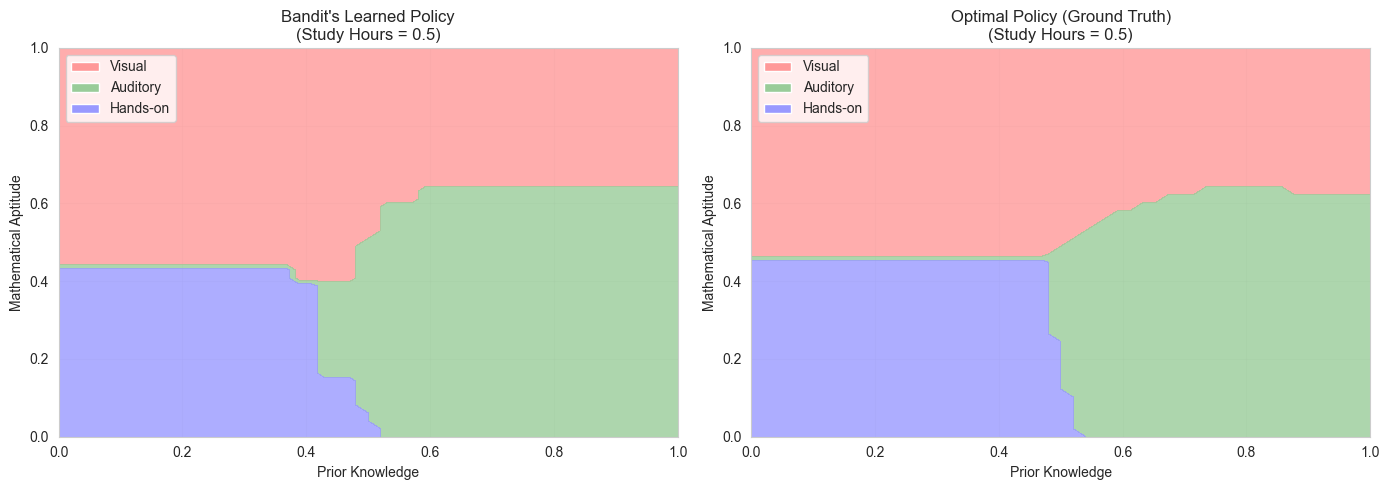


Bandit's decision accuracy compared to optimal: 95.4%


In [11]:
# ============================================================================
# 8. VISUALIZE THE LEARNED DECISION BOUNDARIES
# ============================================================================
# Let's visualize how the bandit learned to assign different lesson types 
# to different student profiles.
# ============================================================================

# Create a grid of student profiles varying two features
# We'll fix study hours at 0.5 and vary prior knowledge and aptitude

n_points = 50
prior_knowledge_range = np.linspace(0, 1, n_points)
aptitude_range = np.linspace(0, 1, n_points)

# Create meshgrid
PK, AP = np.meshgrid(prior_knowledge_range, aptitude_range)

# Store predictions
bandit_predictions = np.zeros_like(PK)
optimal_predictions = np.zeros_like(PK)

for i in range(n_points):
    for j in range(n_points):
        context = np.array([PK[i, j], 0.5, AP[i, j]])  # Fixed study hours = 0.5
        bandit_predictions[i, j] = final_bandit.predict_best_arm(context)
        optimal_predictions[i, j] = ground_truth.get_optimal_arm(context)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bandit's learned policy
im1 = axes[0].contourf(PK, AP, bandit_predictions, levels=[-0.5, 0.5, 1.5, 2.5], 
                        colors=['#ff9999', '#99cc99', '#9999ff'], alpha=0.8)
axes[0].set_xlabel('Prior Knowledge')
axes[0].set_ylabel('Mathematical Aptitude')
axes[0].set_title('Bandit\'s Learned Policy\n(Study Hours = 0.5)')
axes[0].grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#ff9999', label='Visual'),
                   Patch(facecolor='#99cc99', label='Auditory'),
                   Patch(facecolor='#9999ff', label='Hands-on')]
axes[0].legend(handles=legend_elements, loc='upper left')

# Plot 2: Optimal policy (ground truth)
im2 = axes[1].contourf(PK, AP, optimal_predictions, levels=[-0.5, 0.5, 1.5, 2.5], 
                        colors=['#ff9999', '#99cc99', '#9999ff'], alpha=0.8)
axes[1].set_xlabel('Prior Knowledge')
axes[1].set_ylabel('Mathematical Aptitude')
axes[1].set_title('Optimal Policy (Ground Truth)\n(Study Hours = 0.5)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Calculate accuracy
accuracy = np.mean(bandit_predictions == optimal_predictions) * 100
print(f"\nBandit's decision accuracy compared to optimal: {accuracy:.1f}%")

In [12]:
# ============================================================================
# 9. EXAMINE THE LEARNED XGBOOST MODEL
# ============================================================================
# Let's peek inside the trained XGBoost model to see what it learned.
# XGBoost uses feature importance scores to indicate which features were most
# useful for making predictions.
# ============================================================================

print("=" * 80)
print("XGBoost Model Feature Importances")
print("=" * 80)
print()

# Get feature importances from the trained model
importances = final_bandit.model.feature_importances_

# Feature names: [Prior Knowledge, Study Hours, Aptitude, Arm (categorical)]
all_feature_names = [
    "Prior Knowledge",
    "Study Hours",
    "Aptitude",
    "Lesson Type (categorical)",
]

print("Feature Importances (higher = more important for predictions):")
print()
for name, importance in zip(all_feature_names, importances):
    bar = '█' * int(float(importance) * 50)  # Visual bar chart
    print(f"{name:<24}: {float(importance):6.4f} {bar}")

print("\n" + "=" * 80)
print("Model Information")
print("=" * 80)
print(f"Number of boosting rounds: {final_bandit.model.n_estimators}")
print(f"Maximum tree depth: {final_bandit.model.max_depth}")
print(f"Learning rate: {final_bandit.model.learning_rate}")
print(f"Total training samples: {len(final_bandit.X_train)}")

print("\n" + "=" * 80)
print("Ground Truth Comparison")
print("=" * 80)
print("\nTrue feature weights by lesson type:")
print()

for arm in range(3):
    print(f"{lesson_names[arm]} Lesson (Arm {arm}):")
    true_coefs = ground_truth.true_weights[arm]
    for i, feature in enumerate(['Prior Knowledge', 'Study Hours', 'Aptitude']):
        print(f"  {feature:<18}: {true_coefs[i]:>6.3f} (scaled: {true_coefs[i]*30:>6.1f})")
    print()

print("Note: The model treats lesson type as a categorical feature and learns")
print("arm-specific interactions via tree splits.")


XGBoost Model Feature Importances

Feature Importances (higher = more important for predictions):

Prior Knowledge         : 0.3231 ████████████████
Study Hours             : 0.1659 ████████
Aptitude                : 0.3122 ███████████████
Lesson Type (categorical): 0.1988 █████████

Model Information
Number of boosting rounds: 100
Maximum tree depth: 3
Learning rate: 0.1
Total training samples: 2000

Ground Truth Comparison

True feature weights by lesson type:

Visual Lesson (Arm 0):
  Prior Knowledge   :  0.050 (scaled:    1.5)
  Study Hours       :  0.050 (scaled:    1.5)
  Aptitude          :  1.000 (scaled:   30.0)

Auditory Lesson (Arm 1):
  Prior Knowledge   :  1.000 (scaled:   30.0)
  Study Hours       :  0.050 (scaled:    1.5)
  Aptitude          :  0.050 (scaled:    1.5)

Hands-on Lesson (Arm 2):
  Prior Knowledge   :  0.050 (scaled:    1.5)
  Study Hours       :  1.000 (scaled:   30.0)
  Aptitude          :  0.050 (scaled:    1.5)

Note: The model treats lesson type as a ca